In [1]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *
from scipy.interpolate import RectBivariateSpline

In [21]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [3]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 2000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data()
# --- temperature transfer function ---
ells, ks, T_lk = transfer.get_transfer(source=0)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [4]:
T_spline = RectBivariateSpline(ells.astype(float),np.log(ks),T_lk,kx=3,ky=3)
def Delta_T(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks.min()) or np.any(k > ks.max()):
        raise ValueError(f"k is outside CAMB grid: {ks.min()} <= k <= {ks.max()}")
    if np.any(ell < ells.min()) or np.any(ell > ells.max()):
        raise ValueError(f"ell is outside CAMB grid: {ells.min()} <= ell <= {ells.max()}")
    return T_spline.ev(ell, np.log(k))

In [5]:
k_arr = np.logspace(-5,-1.5,1000)

In [6]:
ell_B, ks_B, TB_lk = local.compute_transfer_B()

In [24]:
lmaxB = ell_B.max()

In [8]:
TB_spline = RectBivariateSpline(ell_B.astype(float),np.log(ks_B),TB_lk,kx=3,ky=3)
def Delta_B(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks_B.min()) or np.any(k > ks_B.max()):
        raise ValueError(f"k is outside CAMB grid: {ks_B.min()} <= k <= {ks_B.max()}")
    if np.any(ell < ell_B.min()) or np.any(ell > ell_B.max()):
        raise ValueError(f"ell is outside CAMB grid: {ell_B.min()} <= ell <= {ell_B.max()}")
    return TB_spline.ev(ell, np.log(k))

In [9]:
r_grid = np.logspace(2,5,50)

In [10]:
Xi = local.Xi_func(2000, r_grid, eta0, -2.9, kn=100)

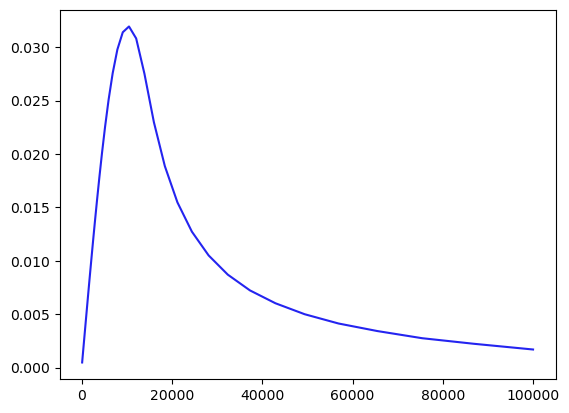

In [11]:
plot(r_grid,Xi[(2,'E')](r_grid))

In [12]:
Upsion = local.Upsilon_func(lmax, r_grid, Delta_T, perturb='TS', kn=100)

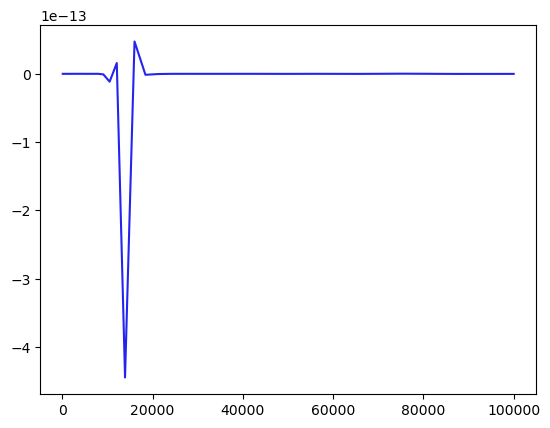

In [13]:
plot(r_grid,Upsion[(12,'L')](r_grid)*Xi[(11,'E')](r_grid)*Xi[(10,'B')](r_grid))

In [14]:
from cmblensplus.utils import cmb

In [15]:
ucl = cmb.read_camb_cls('/global/homes/t/toshiyan/Work/Lib/cmblensplus_dev/example/data/unlensedcls.dat',ftype='scal',output='array')[:,:lmax+1]
lcl = cmb.read_camb_cls('/global/homes/t/toshiyan/Work/Lib/cmblensplus_dev/example/data/lensedcls.dat',ftype='lens',output='array')[:,:lmax+1]

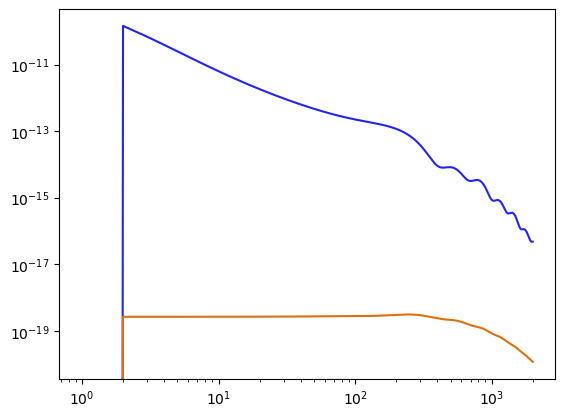

In [16]:
loglog(ucl[0])
loglog(lcl[2])

In [17]:
nlaa = 1e-8
blmax = 20

In [18]:
snr2 = 0.0

ucl0 = ucl[0]
denom_pref = nlaa**2

for l in range(2, blmax):
    ucl_l = ucl0[l]
    denom = ucl_l * denom_pref

    for l1 in range(2, blmax):
        l2_min = max(l1, abs(l - l1), 2)
        l2_max = min(blmax - 1, l + l1)

        for l2 in range(l2_min, l2_max + 1):
            if (l + l1 + l2) % 2 == 0:
                continue

            fac = 1.0 if l1 == l2 else 2.0

            B_val = local.bispec_Taa_odd(l,l1,l2,Upsion,Xi,logrmin=2,logrmax=5,rn=50).imag
            snr2 += fac * B_val**2 / denom

snr = np.sqrt(snr2)

In [19]:
snr*1.8e-16

np.float64(3.018734894239931e-05)

In [25]:
Upsion_B = local.Upsilon_func(lmaxB, r_grid, Delta_B, perturb='BT', kn=100)

In [54]:
blmax = 20

In [55]:
snr2 = 0.0

BB = lcl[2]
denom_pref = nlaa**2

for l in range(2, blmax):
    denom = BB[l] * denom_pref

    for l1 in range(2, blmax):
        l2_min = max(l1, abs(l - l1), 2)
        l2_max = min(blmax - 1, l + l1)

        for l2 in range(l2_min, l2_max + 1):
            if (l + l1 + l2) % 2 == 1:
                continue
            fac = 1.0 if l1 == l2 else 2.0

            B_val = local.bispec_Baa_even(l,l1,l2,Upsion_B,Xi,Xi,logrmin=2,logrmax=5,rn=50)
            snr2 += fac * B_val**2 / denom
            #print(B_val)
snr = np.sqrt(snr2)

In [56]:
snr*1.8e-16*4*np.sqrt(2.)

np.float64(0.053138088746795493)

In [29]:
snr2 = 0.0

BB = lcl[2]
denom_pref = nlaa**2

for l in range(2, blmax):
    denom = BB[l] * denom_pref

    for l1 in range(2, blmax):
        l2_min = max(l1, abs(l - l1), 2)
        l2_max = min(blmax - 1, l + l1)

        for l2 in range(l2_min, l2_max + 1):
            if (l + l1 + l2) % 2 == 0:
                continue
            fac = 1.0 if l1 == l2 else 2.0

            B_val = local.bispec_Baa_odd(l,l1,l2,Upsion_B,Xi,Xi,logrmin=2,logrmax=5,rn=50).imag
            snr2 += fac * B_val**2 / denom
snr = np.sqrt(snr2)

In [30]:
snr*1.8e-16*4*np.sqrt(2.)

np.float64(0.012368086651934425)

In [31]:
from scipy.special import gammaln
import numpy as np

n = -2.9
log_value = gammaln((n + 3) / 2)
value = np.exp(log_value)

In [32]:
value

np.float64(19.470085311255502)